In [1]:
import os
from typing import Literal, Tuple, Optional
import logging
import math

from catboost import CatBoostRegressor
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pycatch22 import catch22_all
from scipy.interpolate import PchipInterpolator
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

from lstm_network import LSTMModel, LSTMTrainer

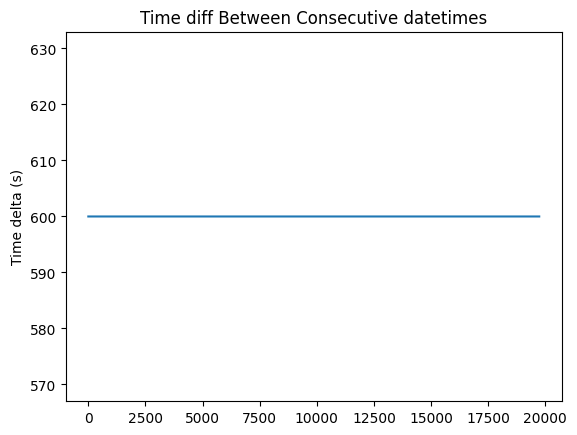

In [10]:
def plot_time_deltas(df: pd.DataFrame, time_col: str) -> None:
    """Calculate time diff between consecutive datetime entries in the specified column,
    and plot these time deltas"""
    df[time_col]= pd.to_datetime(df[time_col])
    diffs       = df[time_col].diff().dropna()
    plt.plot(diffs.dt.total_seconds())
    plt.ylabel('Time delta (s)')
    plt.title('Time diff Between Consecutive datetimes')
    plt.show()

datasets = {"GDELT_USA_LAB":      {"path": "Time-IMM/GDELT_USA_LAB",       "time_col": "date_time", "y": ["AvgTone"]},
            # "ClusterTrace_707":   {"path": "Time-IMM/ClusterTrace_707",    "time_col": "date_time", "y": ["cpu", "memory"]},
            "EPA_air_los_angeles":{"path": "Time-IMM/EPA_air_los_angeles", "time_col": "date_time", "y": ["ozone"]},
            "FNSPID_EXPE":        {"path": "Time-IMM/FNSPID_EXPE",         "time_col": "date_time", "y": ["adj close"]},
            # "ILINet":             {"path": "Time-IMM/ILINet",              "time_col": "date_time", "y": ["TOTAL PATIENTS"]},
            "repohealth_facebook":{"path": "Time-IMM/repohealth_facebook", "time_col": "date_time", "y": ["new_issues"]},
            "studentlife_fc7337": {"path": "Time-IMM/studentlife_fc7337",  "time_col": "date_time", "y": ["sleep_duration"]},
            "power_consumption":  {"path": "power_consumption",            "time_col": "Datetime",  "y": ["PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"]},
            "appliances_energy":  {"path": "appliances_energy",            "time_col": "date",      "y": ["rv1", "rv2"]}}

desired_dataset= "appliances_energy"

df             = pd.read_csv(f"../public_datasets/{datasets[desired_dataset]['path']}.csv")
time_col_name  = datasets[desired_dataset]["time_col"]

"""Pre-processing each dataset"""
try:
    if desired_dataset == "GDELT_USA_LAB":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ClusterTrace_707":
        pass
    elif desired_dataset == "EPA_air_los_angeles":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "FNSPID_EXPE":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ILINet":
        df.drop(["record_id"], axis=1, inplace=True)
        df = df.drop_duplicates(subset=['date_time'], keep='first').reset_index(drop=True) #some rows have same time
    elif desired_dataset == "repohealth_facebook":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "studentlife_fc7337":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "power_consumption":
        df.drop(["PowerConsumption_Zone2", "PowerConsumption_Zone3"], axis=1, inplace=True)
    elif desired_dataset == "appliances_energy":
        df.drop(["rv2"], axis=1, inplace=True)
except Exception as e:
    pass

y_cols = [col for col in datasets[desired_dataset]["y"] if col in df.columns]
df = df.fillna(0)

plot_time_deltas(df, time_col_name)


In [3]:
"""TimeGPT"""
from nixtla import NixtlaClient # timeGPT
from timeGPT import TimeGPTForecaster

from utils import ForecastUtils

NIXTLA_API_KEY = 'nixak-TnuMDCHsSM4hajkuXycqZZrNxwtAIoT9O9H7Q8ZwKl2JuJlazRqIPknwJW1AVHX2yB3yfCAwmAogugqQ'
logging.getLogger("nixtla").setLevel(logging.WARNING)

# interpolate irregular timestamps first
time_delta = df[time_col_name].diff().dropna()
if time_delta.nunique() == 1: # timestamps uniform, skip PCHIP
    df_uniform = df.copy()
else:
    freq       = ForecastUtils.infer_dominant_freq(df, time_col_name)
    df_uniform = ForecastUtils.apply_pchip_interpolation(df, time_col_name, freq)

horizon  = ForecastUtils.compute_horizon(len(df_uniform), fixed_points=20, pct=0.01)
n_train  = len(df_uniform) - horizon
df_train = df_uniform.iloc[:n_train].copy()
df_test  = df_uniform.iloc[n_train:].copy()

forecaster = TimeGPTForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols, api_key=NIXTLA_API_KEY)

"""single window evaluation"""
print("==== single window evaluation ====")
forecast_dict, _ = forecaster.forecast_using_timegpt(df_train, df_test, horizon, use_exogenous_cols=True)
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

"""Multi-window evaluation"""
print("==== multi window evaluation ====")
# Step 1: create windows
n_windows     = 5    # windows to create 
horizon       = 10   # prediction horizon for each window
horizon_frac  = 0.01 # frac of ENTIRE series length
min_window_len= 1008 # len of smallest window (1008 is timeGPT default)
use_exogenous_cols=True
windows_list  = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)

all_forecasts, maes, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_using_timegpt(train_df, test_df, horizon_len=horizon, use_exogenous_cols=use_exogenous_cols)
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j] # shape = H
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        maes.append(mae)
        sizes.append(len(y_true))

# Step 3: compute weighted MAE across windows (horizon = weight)
weighted_mae = sum(MAE * n for MAE, n in zip(maes, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(maes, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")

# # Plot:
# client.plot(df, forecast_df, time_col=time_col_name, target_col=y_cols[0], level=[80,90])

# show last 2% of the history + all predictions
# n = int(len(df) * 0.02)
# df_tail = df.tail(n)
# forecast_tail = forecast_df[forecast_df[time_col_name] >= df_tail[time_col_name].iloc[0]]
# client.plot(df_tail,forecast_tail,time_col=time_col_name,target_col=y_cols[0],level=[80, 90])


Horizon = 1403 steps (fixed_points=20, pct=0.01)
==== single window evaluation ====


KeyboardInterrupt: 

In [11]:
"""SARIMAX"""
from statsmodels.tsa.statespace.sarimax import SARIMAX
from utils import ForecastUtils

class SARIMAXForecaster:
    """Forecast multiple targets using SARIMAX with optional preprocessing."""
    def __init__(self, df: pd.DataFrame, time_col: str, y_cols: list):
        self.df       = df.copy()
        self.time_col = time_col
        self.y_cols   = y_cols
        
        self.scaler_X = StandardScaler()
        self.scaler_Y = StandardScaler()
        
        self.X_cols        = None
        self.forecast_dict = {}
        self.forecast_dfs  = {}

    def _prepare_data(self, df_train: pd.DataFrame, df_test: pd.DataFrame, horizon_len: int):
        """Scale features and split into train/test sets."""
        if self.X_cols is None:
            self.X_cols = [c for c in df_train.columns if c not in [self.time_col] + self.y_cols]

        df_train_scaled              = df_train.copy()
        df_train_scaled[self.X_cols] = self.scaler_X.fit_transform(df_train[self.X_cols])
        df_train_scaled[self.y_cols] = self.scaler_Y.fit_transform(df_train[self.y_cols])
        df_test                      = df_test.iloc[:horizon_len].copy()

        X_future_scaled = pd.DataFrame(self.scaler_X.transform(df_test[self.X_cols]),
                                       columns=self.X_cols, index=df_test.index)
        X_future_scaled = pd.concat([df_test[[self.time_col]], X_future_scaled], axis=1)
        y_true_scaled   = self.scaler_Y.transform(df_test[self.y_cols])
        return df_train_scaled, X_future_scaled, y_true_scaled

    def forecast_using_sarimax(self, df_train: pd.DataFrame, df_test: pd.DataFrame, horizon_len: int,
                               order=(1,0,0), seasonal_order=(0,0,0,0)):
        """Run SARIMAX forecast for all targets with optional exogenous vars."""
        df_train_scaled, X_future_scaled, y_true_scaled = self._prepare_data(df_train, df_test, horizon_len)
        self.forecast_dict, self.forecast_dfs = {}, {}

        for i, target in enumerate(self.y_cols):
            y_train     = df_train_scaled[target]
            exog_train  = df_train_scaled[self.X_cols] if self.X_cols else None
            exog_future = X_future_scaled[self.X_cols] if self.X_cols else None

            model   = SARIMAX(y_train, exog=exog_train, order=order, seasonal_order=seasonal_order)
            results = model.fit(disp=False)

            forecast_scaled = results.get_forecast(steps=horizon_len, exog=exog_future).predicted_mean
            forecast = forecast_scaled.values
            self.forecast_dict[target] = forecast
            self.forecast_dfs[target]  = pd.DataFrame({self.time_col: df_test[self.time_col].iloc[:horizon_len], "SARIMAX": forecast})

            mae = mean_absolute_error(y_true_scaled[:, i], forecast)
            print(f"MAE for col '{target}': {mae:.4f}")
        return self.forecast_dict, y_true_scaled

logging.basicConfig(level=logging.INFO)

# interpolate irregular timestamps first
time_delta = df[time_col_name].diff().dropna()
if time_delta.nunique() == 1:  # timestamps uniform, skip PCHIP
    df_uniform = df.copy()
else:
    freq       = ForecastUtils.infer_dominant_freq(df, time_col_name)
    df_uniform = ForecastUtils.apply_pchip_interpolation(df, time_col_name, freq)

horizon  = ForecastUtils.compute_horizon(len(df_uniform), fixed_points=20, pct=0.01)
n_train  = len(df_uniform) - horizon
df_train = df_uniform.iloc[:n_train].copy()
df_test  = df_uniform.iloc[n_train:].copy()

forecaster = SARIMAXForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols)

print("==== single window evaluation ====")
forecast_dict, y_true_scaled = forecaster.forecast_using_sarimax(df_train, df_test, horizon, 
                                                                 order=(1,0,0), seasonal_order=(0,0,0,0))
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

print("==== multi window evaluation ====")
n_windows      = 5
horizon        = 10
horizon_frac   = 0.01
min_window_len = 1008
use_exogenous_cols = True

windows_list = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, 
                                          horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)
all_forecasts, maes, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_using_sarimax(train_df, test_df, horizon, 
                                                                     order=(1,0,0), seasonal_order=(0,0,0,0))
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j]
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        maes.append(mae)
        sizes.append(len(y_true))

# ---- Weighted MAE ----
weighted_mae = sum(MAE * n for MAE, n in zip(maes, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(maes, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")


Horizon = 198 steps (fixed_points=20, pct=0.01)
==== single window evaluation ====
MAE for col 'rv1': 0.8833
==== multi window evaluation ====
Horizon = 10 steps
Window 0: train shape (1008, 28), test shape (10, 28)
MAE for col 'rv1': 1.0896
Window 1: train shape (5687, 28), test shape (10, 28)
MAE for col 'rv1': 0.4529
Window 2: train shape (10366, 28), test shape (10, 28)
MAE for col 'rv1': 0.9008
Window 3: train shape (15045, 28), test shape (10, 28)
MAE for col 'rv1': 0.9551
Window 4: train shape (19725, 28), test shape (10, 28)
MAE for col 'rv1': 0.7905
Final MAE: mean ± std= {0.8378}{0.2152}


In [ ]:
from timesfm import TimesFmHparams, TimesFm, TimesFmCheckpoint

# Hyperparameters
hparams = TimesFmHparams(
    backend="jax",
    per_core_batch_size=32,
    horizon_len=128,
    num_layers=20,
    context_len=512,
    use_positional_embedding=True,)

# Local checkpoint folder containing 'checkpoint'
checkpoint = TimesFmCheckpoint(local_dir="interim_data")

# Initialize model
model = TimesFm(hparams=hparams, checkpoint=checkpoint)

# Load manually (if needed)
# model.load_from_checkpoint("interim_data/checkpoint", checkpoint_type=CheckpointType.FLAX)
model.load_from_checkpoint(repo_id="google/timesfm-1.0-200m")#, checkpoint_type=CheckpointType.FLAX)

# Forecast example
y = np.arange(100)
forecast = model.forecast(y, horizon=10)
print(forecast)


In [ ]:
"""Applying metrics on X vs z"""

# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # Split your original data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Encode train/test via VAE
# z_train = vae.encoder.predict(X_train)  # shape (num_samples, latent_dim)
# z_test  = vae.encoder.predict(X_test)

# # --- Predictor on raw X ---
# model_X = LinearRegression()
# model_X.fit(X_train.reshape(X_train.shape[0], -1), y_train)  # flatten if needed
# y_pred_X = model_X.predict(X_test.reshape(X_test.shape[0], -1))

# # --- Predictor on latent z ---
# model_z = LinearRegression()
# model_z.fit(z_train, y_train)
# y_pred_z = model_z.predict(z_test)

# # --- Metrics ---
# def print_metrics(y_true, y_pred, name):
#     mse = mean_squared_error(y_true, y_pred)
#     mae = mean_absolute_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     print(f"{name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# print_metrics(y_test, y_pred_X, "Predictor on X")
# print_metrics(y_test, y_pred_z, "Predictor on z")


In [ ]:
from downsampling import LTTBDownsampler, OtherDownsamplers

def df_plotter(df, df_downsampled, col_to_plot: int, time_col: str) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(df[time_col], df.iloc[:, col_to_plot], alpha=0.8, linewidth=2)
    plt.plot(df_downsampled[time_col], df_downsampled.iloc[:, col_to_plot], alpha=0.8, linewidth=1)
    plt.legend(['Original', 'Downsampled'])
    plt.tight_layout()
    plt.show()

def _add_time_features(df: pd.DataFrame, y_col: str, time_col: str = 'Datetime', lag_amount: int = 1, rolling_window: int = 3) -> pd.DataFrame:
    df = df.copy()
    df.loc[:, 'hour']      = df[time_col].dt.hour
    df.loc[:, 'dayofweek'] = df[time_col].dt.dayofweek
    df.loc[:, f'lag_{lag_amount}'] = df[y_col].shift(lag_amount)
    df.loc[:, f'rolling_mean_{rolling_window}'] = df[y_col].rolling(rolling_window).mean()
    return df.dropna()


class SplitterScaler:
    @staticmethod
    def split_X_and_y(df, time_col: str, y) -> tuple:
        X = df.drop([time_col]+ y, axis=1)
        y = df[y]
        return X, y
        # y1= df[['PowerConsumption_Zone1']]
        # y2= df[['PowerConsumption_Zone2']]
        # y3= df[['PowerConsumption_Zone3']]
        # return X, y, y1, y2, y3

    @staticmethod
    def traintest_split_then_scale(X: pd.DataFrame, y: pd.Series) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        scaler_X       = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled  = scaler_X.transform(X_test)

        scaler_y       = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train)
        y_test_scaled  = scaler_y.transform(y_test)
        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y

    @staticmethod
    def scale_X_and_y(X: pd.DataFrame, y: pd.DataFrame):
        """Scale features X and target y using StandardScaler.
        Returns scaled arrays and fitted scalers"""
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)
        return X_scaled, y_scaled, (scaler_X, scaler_y)

    @staticmethod
    def scale_X_and_y_latents(X_train: pd.DataFrame | np.ndarray, X_valid: pd.DataFrame | np.ndarray,
                            y_train: pd.DataFrame | np.ndarray, y_valid: pd.DataFrame | np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
        """Fit scalers on X_train and y_train, transform both train and valid sets.
        Returns scaled X_train, X_valid, y_train, y_valid, scaler_X, scaler_y"""
        scaler_X  = StandardScaler().fit(X_train)
        X_train_s = scaler_X.transform(X_train)
        X_valid_s = scaler_X.transform(X_valid)

        y_train   = np.asarray(y_train).reshape(-1, 1)
        y_valid   = np.asarray(y_valid).reshape(-1, 1)
        scaler_y  = StandardScaler().fit(y_train)
        y_train_s = scaler_y.transform(y_train)
        y_valid_s = scaler_y.transform(y_valid)

        return X_train_s, X_valid_s, y_train_s, y_valid_s, scaler_X, scaler_y


class TrainerAndEvaluator:

    @staticmethod
    def train_catboost_model(X_train_scaled, y_train_scaled):
        model = CatBoostRegressor(iterations=1300, depth=8, learning_rate=0.15, l2_leaf_reg=2, loss_function='RMSE',
                                  random_seed=42, verbose=0, early_stopping_rounds=100, task_type='CPU', bagging_temperature=3)
        model.fit(X_train_scaled, y_train_scaled.ravel())
        return model

    @staticmethod
    def train_and_evaluate_model(train_df: Optional[pd.DataFrame] = None, test_df: Optional[pd.DataFrame] = None,
                                 X_train: Optional[np.ndarray] = None, X_test: Optional[np.ndarray] = None,
                                 y_train: Optional[np.ndarray] = None, y_test: Optional[np.ndarray] = None,
                                 scaler_X: Optional[StandardScaler] = None) -> Tuple[float, float]:
        """Train and evaluate CatBoost. If X/y provided, use them directly.
        Otherwise, extract features from train_df/test_df"""
        
        if X_train is None or y_train is None:
            # Mode 1: from DataFrames
            X, y = SplitterScaler.split_X_and_y(train_df, time_col_name, y_cols)
            X_train_s, X_test_s, y_train_s, y_test_s, _ = SplitterScaler.traintest_split_then_scale(X, y)
        else:
            # Mode 2: from arrays
            if scaler_X:
                X_train_s = scaler_X.transform(X_train)
                X_test_s  = scaler_X.transform(X_test)
            else:
                X_train_s, X_test_s = X_train, X_test  # already scaled
            y_train_s, y_test_s = y_train, y_test

        model  = TrainerAndEvaluator.train_catboost_model(X_train_s, y_train_s)
        y_pred = model.predict(X_test_s)

        # --- metrics ---
        if y_test_s.ndim == 1 or y_test_s.shape[1] == 1:
            rmse  = float(np.sqrt(mean_squared_error(y_test_s, y_pred)))
            nrmse = float(rmse / (y_test_s.max() - y_test_s.min()))
        else:
            rmses = [np.sqrt(mean_squared_error(y_test_s[:, i], y_pred[:, i]))
                     for i in range(y_test_s.shape[1])]
            rmse  = float(np.mean(rmses))
            nrmse = float(np.mean([
                r / (y_test_s[:, i].max() - y_test_s[:, i].min())
                for i, r in enumerate(rmses)]))
        return rmse, nrmse

def downsample_and_evaluate(df, new_points_per_col, compression_ratio_list, rmse_list, nrmse_list, method, rdp_epsilon=0.1):
    """Downsample df, evaluate model on original and compressed, store metrics."""
    if method == "union_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_union(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "intersection_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_intersection(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "union_lttb_with_spikes":
        df_downsampled = LTTBDownsampler.downsample_lttb_union_with_spikes(df, time_col=time_col_name, max_points_per_col=new_points_per_col,\
                                                                           spike_thresh=4, spike_method='mad')
    elif method == "union_rdp":
        df_downsampled = OtherDownsamplers.downsample_using_rdp_union(df, time_col=time_col_name, epsilon=rdp_epsilon)
    else:
        raise ValueError(f"Unknown downsampling method: {method}")

    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)
    # print(f"orig. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

    compression_ratio = len(df) / len(df_downsampled)
    # print(f"data compressed {compression_ratio:.2f}x")
    rmse_c, nrmse_c = TrainerAndEvaluator.train_and_evaluate_model(df_downsampled)
    # print(f"compress. RMSE: {rmse_c:.3f}, norm RMSE: {nrmse_c:.3%}")

    compression_ratio_list.append(compression_ratio)
    rmse_list.append(rmse_c)
    nrmse_list.append(nrmse_c)
    return compression_ratio_list, rmse_list, nrmse_list


In [ ]:
"""timeVAE preprocessing (windowing)"""

def create_windows(data: np.ndarray, window_size: int, step_size: int) -> np.ndarray:
    N      = (data.shape[0] - window_size) // step_size + 1
    windows= np.array([data[i*step_size:i*step_size+window_size] for i in range(N)])
    return windows

df_only_X   = df.drop(columns=[time_col_name] + y_cols)
df_np       = df_only_X.values
window_size = 20
step_size   = window_size // 4
X_windows   = create_windows(df_np, window_size, step_size)
y_windows   = create_windows(df[y_cols].values, window_size, step_size)

print("X windows shape:", X_windows.shape, "y windows shape:", y_windows.shape)

# Save to ./data/ + timeVAE repo
should_we_save_in_timeVAE = True
if should_we_save_in_timeVAE:
    os.makedirs('../interim_data', exist_ok=True)
    np.savez_compressed(f"../interim_data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))
    np.savez_compressed(f"../../timeVAE/data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))


In [ ]:
"""predicting y on latents z"""
z_train = np.load(f"../interim_data/z_train_{desired_dataset}.npy")
z_valid = np.load(f"../interim_data/z_valid_{desired_dataset}.npy")
print(f"z_train shape: {z_train.shape}, z_valid shape: {z_valid.shape}")

y_squeezed = y_windows[:, -1, 0].reshape(-1, 1)

# y train/valid shaped like z_train/valid
n_train = z_train.shape[0]
n_valid = z_valid.shape[0]
y_train = y_squeezed[:n_train]
y_valid = y_squeezed[n_train:n_train + n_valid]

print("y_train/y_valid shapes:", y_train.shape, y_valid.shape)

# z_train_df = pd.DataFrame(z_train, columns=[f"z{i}" for i in range(z_train.shape[1])])
# z_valid_df = pd.DataFrame(z_valid, columns=[f"z{i}" for i in range(z_valid.shape[1])])

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=z_train, X_test=z_valid,
                                                           y_train=y_train, y_test=y_valid)
print(f"RMSE: {rmse:.4f}, NRMSE: {nrmse:.4f}")


In [ ]:
"""catch22"""

def catch22_features_from_windows(X_windows: np.ndarray, y_windows: np.ndarray, which_y: str) -> tuple[np.ndarray, np.ndarray]:
    """Apply catch22 to each window/channel and return (features, targets).
    X_windows: shape (n_windows, window_size, n_channels)
    y_windows: shape (n_windows, window_size, n_targets)"""
    
    n_windows, _, n_channels = X_windows.shape
    feats = np.empty((n_windows, n_channels * 22), dtype=float)
    
    for i in range(n_windows):
        channel_feats = [catch22_all(X_windows[i, :, ch])['values']
                         for ch in range(n_channels)]
        feats[i] = np.concatenate(channel_feats)
    
    # Take last value in each target window
    if which_y == "last":
        y_out = y_windows[:, -1, :]
    elif which_y == "mean":
        y_out = np.mean(y_windows, axis=1)
    return feats, y_out

X_c22, y_c22 = catch22_features_from_windows(X_windows, y_windows, which_y="last")
X_train, X_test, y_train, y_test = train_test_split(X_c22, y_c22, test_size=0.2, random_state=42)
print(f"shapes: X_train {X_train.shape}, X_test {X_test.shape}, y_train {y_train.shape}, y_test {y_test.shape}")

# X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, _ = SplitterScaler.traintest_split_then_scale(X_c22, y_c22)

if y_train.shape[1] == 1:
    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=X_train, X_test=X_test,
                                                               y_train=y_train.ravel(), y_test=y_test.ravel())
    print(f"Train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")
else:
    rmses   = []
    nrmse_s = []
    for i in range(y_train.shape[1]):
        rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train[:, i],
            y_test=y_test[:, i])
        rmses.append(rmse)
        nrmse_s.append(nrmse)
    print("Mean RMSE:", np.mean(rmses))
    print("Mean NRMSE:", np.mean(nrmse_s))


In [ ]:
"""Eval cell"""
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)
rmse, nrmse       = TrainerAndEvaluator.train_and_evaluate_model(df_train, df_test)
print(f"Original train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

N_VW   = 10

N_LTTB = 2
spike_method      = 'zscore' # 'zscore' or 'mad'
spike_method_thres= 3

rdp_epsilon       = 1
subsampling_ratio = 100
N_last_rows       = 100

lttb_union_train = LTTBDownsampler.downsample_using_lttb_union(df_train, time_col=time_col_name,
                                                               max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_train, df_test)
print(f"LTTB union ({N_LTTB=})")
print(f"data compressed {len(df_train)/len(lttb_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_intersect_train = LTTBDownsampler.downsample_using_lttb_intersection(df_train, time_col=time_col_name,
                                                                          max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_intersect_train, df_test)
print("LTTB intersection")
print(f"data compressed {len(df_train)/len(lttb_intersect_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_union_spikes_train = LTTBDownsampler.downsample_lttb_union_with_spikes(df_train, time_col=time_col_name,
                                                                            max_points_per_col=len(df_train) // N_LTTB,
                                                                            spike_thresh=spike_method_thres, spike_method=spike_method)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_spikes_train, df_test)
print(f"LTTB union +spikes ({spike_method=})")
print(f"data compressed {len(df_train)/len(lttb_union_spikes_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

rdp_union_train = OtherDownsamplers.downsample_using_rdp_union(df_train, time_col=time_col_name, epsilon=rdp_epsilon)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(rdp_union_train, df_test)
print(f"RDP union ({rdp_epsilon=})")
print(f"data compressed {len(df_train)/len(rdp_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

vw_union_train = OtherDownsamplers.downsample_using_vw_union(df_train, time_col=time_col_name, target_points=len(df_train) // N_VW)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(vw_union_train, df_test)
print(f"VW union ({N_VW=})")
print(f"data compressed {len(df_train)/len(vw_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

subsample_train = OtherDownsamplers.subsample_timeseries(df_train, subsampling_ratio=subsampling_ratio)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(subsample_train, df_test)
print(f"Subsample ({subsampling_ratio=})")
print(f"data compressed {len(df_train)/len(subsample_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

last_N_rows_train = OtherDownsamplers.get_last_N_rows(df_train, N_rows=N_last_rows)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(last_N_rows_train, df_test)
print(f"Last N rows ({N_last_rows=})")
print(f"data compressed {len(df_train)/len(last_N_rows_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")


# df_plotter(df, lttb_union_train, 1, time_col_name)

In [ ]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

def plot_corr_matrix(df: pd.DataFrame, title: str = "Feature Correlation Matrix") -> None:
    """Plot heatmap of Pearson correlation matrix for the DataFrame features"""
    corr = df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_autocorr(series: pd.Series, lags: int = 40, title: str = None) -> None:
    """Plot autocorrelation function (ACF) for a pandas Series"""
    plt.figure(figsize=(8, 4))
    plot_acf(series.dropna(), lags=lags, alpha=0.05)
    plt.title(title or f"Autocorrelation (up to {lags} lags)")
    plt.tight_layout()
    plt.show()

# plot_corr_matrix(df)
# plot_corr_matrix(df_downsampled)
# plot_corr_matrix(df_downsampled2)

plot_autocorr(df['act_still'], lags=10)
plot_autocorr(df_downsampled['act_still'], lags=10)
plot_autocorr(df_downsampled2['act_still'], lags=10)

In [ ]:
"""LSTM"""
# ===== Example usage =====
n_samples  = 100
n_rows     = 10
n_features = 15
X = torch.randn(n_samples, n_rows, n_features)
y = torch.randn(n_samples, 1)

# Train/val split
train_X, val_X = X[:80], X[80:]
train_y, val_y = y[:80], y[80:]

# Model/optimizer/loss
model     = LSTMModel(input_size=n_features, hidden_size=64, num_layers=2, output_size=1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
trainer = LSTMTrainer(model, optimizer, criterion)
trainer.fit(train_X, train_y, val_X, val_y, epochs=300)

# Inference
new_seq    = torch.randn(1, n_rows, n_features)  # batch=1, seq=10, features=15
prediction = trainer.predict(new_seq)
print("Prediction:", prediction)


In [ ]:
"""Make scatterplot of compressions vs rmse"""
compression_ratio_list, rmse_list, nrmse_list = [], [], []
new_points_per_col_ratio = list(range(2, 10, 8))
new_points_per_col = [int(len(df) / ratio) for ratio in new_points_per_col_ratio]

for i, point_n in enumerate(new_points_per_col):
    compression_ratio_list, rmse_list, nrmse_list = downsample_and_evaluate(
        df, point_n, compression_ratio_list, rmse_list, nrmse_list, rdp_epsilon=0.1, method="union_rdp")

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)

plt.figure(figsize=(8, 5))
# plt.scatter(compression_ratio_list, nrmse_list, label="Norm. RMSE", marker="o")
# plt.scatter(1, nrmse, label="original")

plt.scatter(compression_ratio_list, rmse_list, label="RMSE", marker="x")
plt.scatter(1, rmse, label="original")

plt.xlabel("Compression Ratio")
plt.ylabel("RMS error")
plt.title("Error vs Compression Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# """Choose good epsilon for RDP"""
# for col in df.columns:
#     if col == time_col_name:
#         continue
#     if pd.api.types.is_datetime64_any_dtype(df[time_col_name]):
#         x_vals = df[time_col_name].astype("int64")
#     else:
#         x_vals = df[time_col_name].values

#     coords = np.column_stack((x_vals, df[col].values))
#     eps1 = OtherDownsamplers.choose_rdp_epsilon(coords, method="mad", factor=1.0)
#     eps2 = OtherDownsamplers.choose_rdp_epsilon(coords, method="std", factor=1.0)
#     eps3 = OtherDownsamplers.choose_rdp_epsilon(coords, method="fraction", factor=1e-3)

#     print(f"RDP epsilon (mad): {eps1:.3f}, (std): {eps2:.3f}, (fraction): {eps3:.3f}")